
=== ELITE CAPTURE THRESHOLD REGRESSION: GLOBAL PANEL (ALL COUNTRIES) ===
Searching 1000 thresholds between 22.9% and 97.0% Debt-to-GDP...


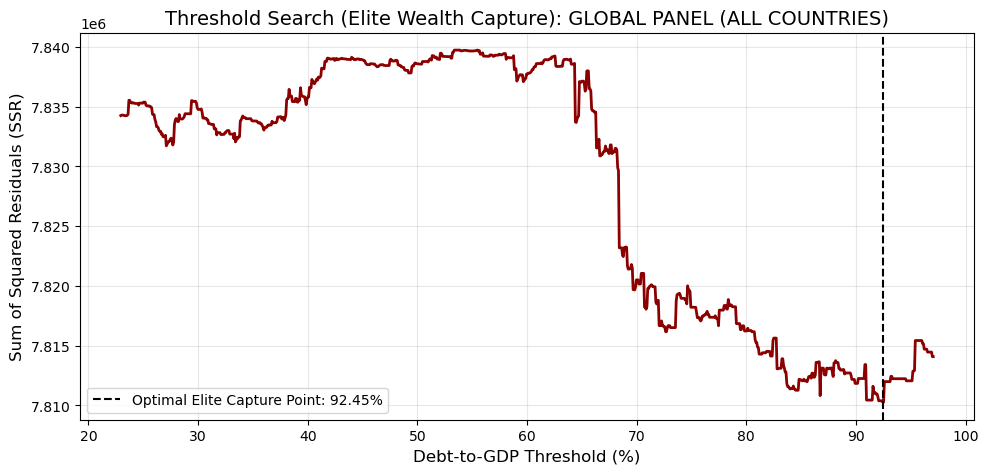


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 92.45% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -5.9795     11.693    -0.5114     0.6092     -28.924      16.965
Debt_Below_Gamma                       0.1501     0.1162     1.2916     0.1968     -0.0779      0.3780
Debt_Above_Gamma                      -0.1306     0.1647    -0.7927     0.4281     -0.4538      0.1926
GDP growth (annual %)                  0.4686     0.4077     1.1496     0.2506     -0.3313      1.2685
Gross capital formation (% of GDP)     0.6901     0.5111     1.3503     0.1772     -0.3127      1.6929
Inflation (Annual %)                   0.0220     0.1674     0.1313     0.8956     -0.3065      0.3505

>> 

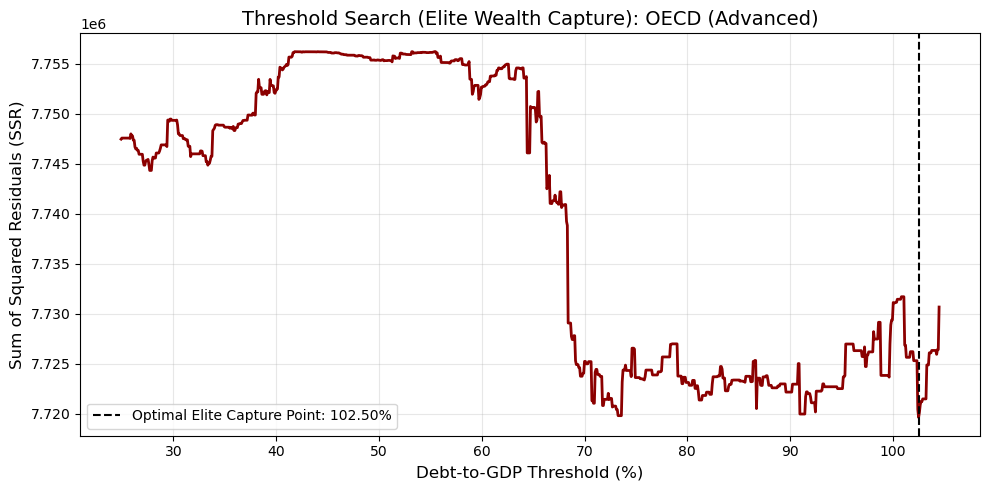


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 102.50% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -9.4138     14.320    -0.6574     0.5111     -37.523      18.695
Debt_Below_Gamma                       0.2167     0.2111     1.0266     0.3049     -0.1976      0.6310
Debt_Above_Gamma                      -0.1039     0.1777    -0.5845     0.5590     -0.4527      0.2449
GDP growth (annual %)                  1.0153     0.6524     1.5564     0.1200     -0.2652      2.2958
Gross capital formation (% of GDP)     0.6587     0.6776     0.9721     0.3313     -0.6714      1.9888
Inflation (Annual %)                   0.3109     0.4287     0.7253     0.4685     -0.5305      1.1524

>>

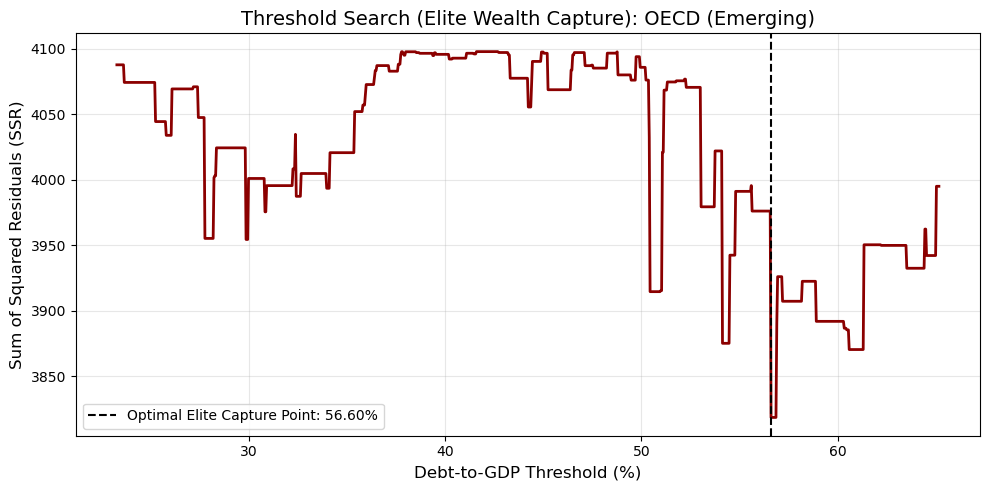


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 56.60% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -10.074     9.0407    -1.1143     0.2676     -27.990      7.8429
Debt_Below_Gamma                       0.0301     0.0764     0.3941     0.6943     -0.1214      0.1816
Debt_Above_Gamma                       0.1440     0.0719     2.0025     0.0477      0.0015      0.2864
GDP growth (annual %)                 -0.4272     0.2934    -1.4562     0.1482     -1.0086      0.1542
Gross capital formation (% of GDP)     0.7492     0.2979     2.5151     0.0133      0.1589      1.3395
Inflation (Annual %)                   0.0145     0.0538     0.2688     0.7886     -0.0922      0.1212

>> 

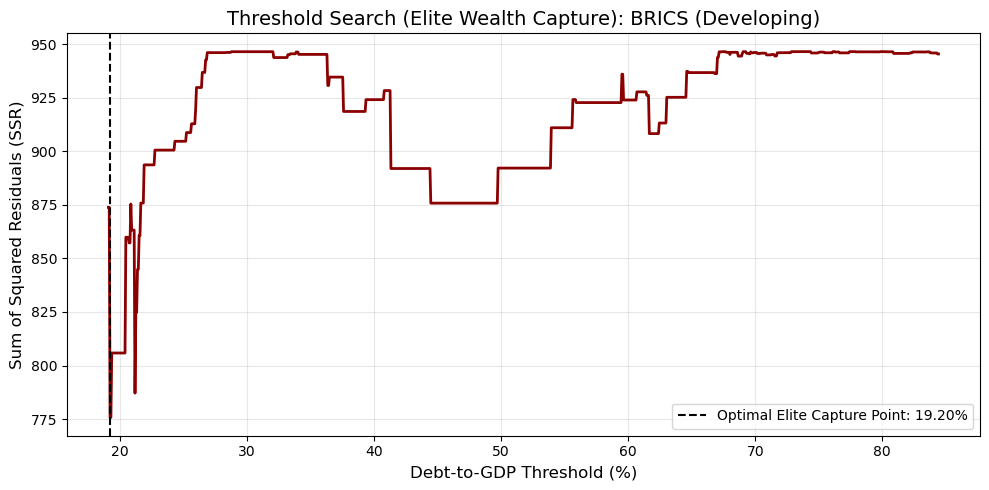


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 19.20% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                  4.2561     2.7681     1.5376     0.1271     -1.2307      9.7429
Debt_Below_Gamma                       0.3756     0.1306     2.8760     0.0049      0.1167      0.6344
Debt_Above_Gamma                      -0.0110     0.0208    -0.5320     0.5958     -0.0522      0.0301
GDP growth (annual %)                 -0.3320     0.1612    -2.0600     0.0418     -0.6515     -0.0125
Gross capital formation (% of GDP)     0.4850     0.1160     4.1806     0.0001      0.2550      0.7149
Inflation (Annual %)                   0.0156     0.0352     0.4420     0.6594     -0.0542      0.0854

>> 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from linearmodels.panel import PanelOLS
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. LOAD MASTER DATA & CALCULATE WEALTH RATIO
# ==============================================================================
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_file = PROCESSED_DIR / "master_panel_data.csv"

df = pd.read_csv(master_file)
df = df.set_index(['Country Name', 'Year'])

BRICS_NATIONS = ["Brazil", "Russia", "India", "China", "Egypt", "United Arab Emirates"]
OECD_EMERGING = ["Chile", "Colombia", "Costa Rica", "Turkey", "Hungary", "Poland"]

def categorize_economy(country):
    if country in BRICS_NATIONS: return 'BRICS (Developing)'
    elif country in OECD_EMERGING: return 'OECD (Emerging)'
    else: return 'OECD (Advanced)'

df['Economic_Bloc'] = [categorize_economy(c) for c, y in df.index]

# Calculate the Elite Capture Ratio
TOP_10_COL = 'Wealth Inequality (Top 10%)'
BOTTOM_50_COL = 'Wealth Inequality (Bottom 50%)'
df['Wealth_Ratio_Top10_to_Bottom50'] = df[TOP_10_COL] / df[BOTTOM_50_COL]

# Handle potential infinite values if bottom 50% wealth is zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)

Y_VAR = 'Wealth_Ratio_Top10_to_Bottom50'
DEBT_VAR = 'General Government Debt (% of GDP)'

# Standard WID controls mapping over from our base models
EXOG_VARS = [
    'GDP growth (annual %)',
    'Gross capital formation (% of GDP)',
    'Inflation (Annual %)'
]

# ==============================================================================
# 2. PANEL THRESHOLD GRID SEARCH ALGORITHM (ELITE CAPTURE)
# ==============================================================================
def run_threshold_regression(data, bloc_name):
    print(f"\n{'='*85}")
    print(f"=== ELITE CAPTURE THRESHOLD REGRESSION: {bloc_name.upper()} ===")
    print(f"{'='*85}")
    
    reg_data = data[[Y_VAR, DEBT_VAR] + EXOG_VARS].dropna()
    
    if len(reg_data) < 30:
        print("Skipping due to insufficient data.")
        return
        
    min_debt = reg_data[DEBT_VAR].quantile(0.15)
    max_debt = reg_data[DEBT_VAR].quantile(0.85)
    
    grid = np.linspace(min_debt, max_debt, 1000)
    
    best_ssr = np.inf
    best_gamma = None
    best_res = None
    ssr_history = []
    
    print(f"Searching 1000 thresholds between {min_debt:.1f}% and {max_debt:.1f}% Debt-to-GDP...")
    
    for gamma in grid:
        reg_data['Debt_Below_Gamma'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] <= gamma)
        reg_data['Debt_Above_Gamma'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] > gamma)
        
        Y = reg_data[Y_VAR]
        X = sm.add_constant(reg_data[['Debt_Below_Gamma', 'Debt_Above_Gamma'] + EXOG_VARS])
        
        model = PanelOLS(Y, X, entity_effects=True, time_effects=True)
        res = model.fit(cov_type='robust')
        
        ssr = float(res.resids.squeeze().dot(res.resids.squeeze()))
        ssr_history.append((gamma, ssr))
        
        if ssr < best_ssr:
            best_ssr = ssr
            best_gamma = gamma
            best_res = res

    # --- 3. VISUALIZATION OF THE THRESHOLD SEARCH ---
    gammas, ssrs = zip(*ssr_history)
    
    plt.figure(figsize=(10, 5))
    plt.plot(gammas, ssrs, color='darkred', linewidth=2)
    plt.axvline(x=best_gamma, color='black', linestyle='--', label=f'Optimal Elite Capture Point: {best_gamma:.2f}%')
    plt.title(f'Threshold Search (Elite Wealth Capture): {bloc_name}', fontsize=14)
    plt.xlabel('Debt-to-GDP Threshold (%)', fontsize=12)
    plt.ylabel('Sum of Squared Residuals (SSR)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 4. PRINT BEST MODEL RESULTS ---
    print(f"\n>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: {best_gamma:.2f}% DEBT-TO-GDP <<\n")
    print(best_res.summary.tables[1])

    # ---------------------------------------------------------
    # TEST 1: One-Way ANOVA on the Dependent Variable
    # ---------------------------------------------------------
    mask_low = reg_data[DEBT_VAR] <= best_gamma
    mask_high = reg_data[DEBT_VAR] > best_gamma

    y_low = reg_data[mask_low][Y_VAR].dropna()
    y_high = reg_data[mask_high][Y_VAR].dropna()

    f_stat_anova, p_val_anova = stats.f_oneway(y_low, y_high)

    print("\n>> 1. ONE-WAY ANOVA (Difference in Means across Regimes):")
    print(f"   - Low Debt Regime Mean ({Y_VAR}):  {y_low.mean():.4f}")
    print(f"   - High Debt Regime Mean ({Y_VAR}): {y_high.mean():.4f}")
    print(f"   - F-Statistic: {f_stat_anova:.4f}")
    print(f"   - P-Value:     {p_val_anova:.4e}")
    if p_val_anova < 0.05:
        print("   -> Conclusion: SIGNIFICANT difference in macroeconomic outcomes between regimes.")
    else:
        print("   -> Conclusion: NO significant difference in outcomes between regimes.")

    # ---------------------------------------------------------
    # TEST 2: Wald F-Test on Regression Coefficients 
    # ---------------------------------------------------------
    print("\n>> 2. WALD F-TEST (Structural Break in Debt Coefficients):")
    print("   - Null Hypothesis (H0): Debt_Below_Gamma coefficient == Debt_Above_Gamma coefficient")

    try:
        # Robust restriction formulation for linearmodels
        idx = best_res.params.index
        R = pd.DataFrame(np.zeros((1, len(idx))), columns=idx)
        R.loc[0, 'Debt_Below_Gamma'] = 1
        R.loc[0, 'Debt_Above_Gamma'] = -1
        
        wald = best_res.wald_test(restriction=R)
        print(f"   - F-Statistic: {wald.stat:.4f}")
        print(f"   - P-Value:     {wald.pval:.4e}")
        if wald.pval < 0.05:
            print("   -> Conclusion: SIGNIFICANT structural break. Debt efficiency fundamentally shifts across the threshold.")
        else:
            print("   -> Conclusion: NO significant structural break.")
    except Exception as e:
        print(f"   -> Could not perform Wald test. Error: {e}")

    print("="*85 + "\n")

# ==============================================================================
# 3. EXECUTE FOR GLOBAL PANEL & CORE BLOCS
# ==============================================================================
if __name__ == "__main__":
    
    # 1. RUN GLOBAL BASELINE (All Countries Combined)
    run_threshold_regression(df, "GLOBAL PANEL (ALL COUNTRIES)")
    
    # 2. RUN INDIVIDUAL BLOCS
    for bloc in ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']:
        df_bloc = df[df['Economic_Bloc'] == bloc]
        run_threshold_regression(df_bloc, bloc)